<a href="https://colab.research.google.com/github/narsimha1603/Major-Project/blob/main/Code%20v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from mlxtend.frequent_patterns import apriori, association_rules
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
print('Deprecation warnings have been suppressed.')

Deprecation warnings have been suppressed.


In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Creating synthetic data since the CSV is missing
np.random.seed(42)
dates = pd.date_range(start='2010-01-01', end='2023-09-09', freq='D')
n = len(dates)

data = pd.DataFrame({
    'Date': dates,
    'Temperature (°C)': np.random.uniform(20, 35, n),
    'Rainfall (mm)': np.random.uniform(0, 200, n),
    'Humidity (%)': np.random.uniform(40, 90, n),
    'Dengue_Cases': np.random.poisson(lam=10, size=n) + (np.sin(np.linspace(0, 10*np.pi, n)) * 5 + 10).astype(int)
})

data.set_index('Date', inplace=True)
data = data.asfreq('D').ffill()

scaler = MinMaxScaler()
data[['Temperature (°C)','Rainfall (mm)','Humidity (%)']] = scaler.fit_transform(
    data[['Temperature (°C)','Rainfall (mm)','Humidity (%)']])

print("Synthetic Dataset Generated and Preprocessed Successfully")

Synthetic Dataset Generated and Preprocessed Successfully


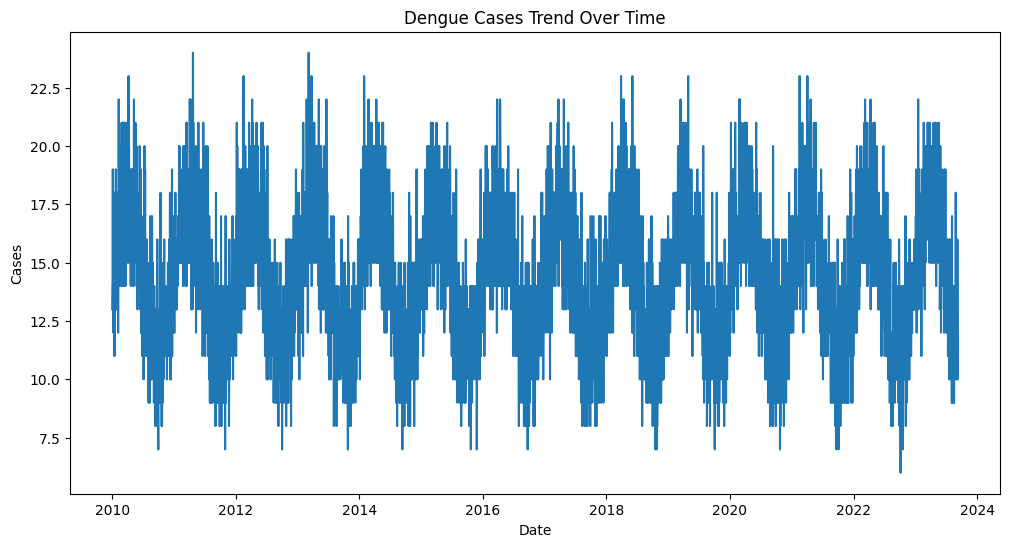

In [ ]:
#DATA UNDERSTANDING
plt.figure(figsize=(12,6))
plt.plot(data.index, data['Dengue_Cases'])
plt.title("Dengue Cases Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.show()

In [ ]:
#DATA PREPROCESSING Handle Missing Values
data = data.ffill()

In [ ]:
#Normalize Weather Variables
scaler = MinMaxScaler()
data[['Temperature (°C)','Rainfall (mm)','Humidity (%)']] = scaler.fit_transform(
    data[['Temperature (°C)','Rainfall (mm)','Humidity (%)']])

In [ ]:
#Stationarity Test (ADF)
result = adfuller(data['Dengue_Cases'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])
if result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is Not Stationary")

ADF Statistic: -4.128511030014541
p-value: 0.0008686016565226949
Series is Stationary


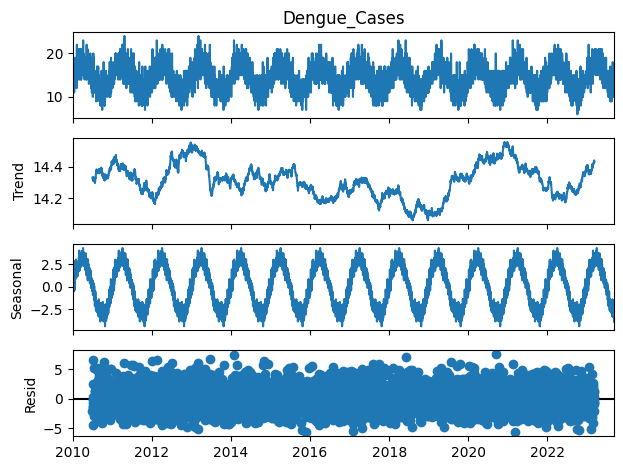

In [ ]:
#TIME SERIES DECOMPOSITION
decomposition = seasonal_decompose(data['Dengue_Cases'], model='additive', period=365)
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid
decomposition.plot()
plt.show()

In [ ]:
#ASSOCIATION RULE MINING (ARM MODEL)
arm_data = data.copy()
arm_data['High_Temp'] = arm_data['Temperature (°C)'] > arm_data['Temperature (°C)'].mean()
arm_data['High_Rain'] = arm_data['Rainfall (mm)'] > arm_data['Rainfall (mm)'].mean()
arm_data['High_Humidity'] = arm_data['Humidity (%)'] > arm_data['Humidity (%)'].mean()
arm_data['High_Cases'] = arm_data['Dengue_Cases'] > arm_data['Dengue_Cases'].mean()
arm_df = arm_data[['High_Temp','High_Rain','High_Humidity','High_Cases']]
frequent = apriori(arm_df, min_support=0.3, use_colnames=True)
rules = association_rules(frequent, metric="confidence", min_threshold=0.6)
print("\nAssociation Rules")
print(rules[['antecedents','consequents','support','confidence']])


Association Rules
                               antecedents  \
0                              (High_Temp)   
1                              (High_Rain)   
2                              (High_Temp)   
3                          (High_Humidity)   
4                              (High_Temp)   
5                             (High_Cases)   
6                              (High_Rain)   
7                          (High_Humidity)   
8                              (High_Rain)   
9                             (High_Cases)   
10                         (High_Humidity)   
11                            (High_Cases)   
12              (High_Temp, High_Humidity)   
13                  (High_Temp, High_Rain)   
14              (High_Rain, High_Humidity)   
15                             (High_Temp)   
16                         (High_Humidity)   
17                             (High_Rain)   
18                 (High_Temp, High_Cases)   
19                 (High_Rain, High_Cases)   
20             

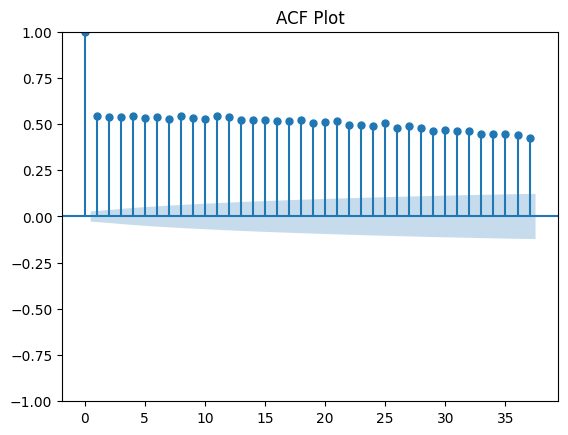

In [ ]:
#PARAMETER ESTIMATION (ACF & PACF)ACF Graph
plot_acf(data['Dengue_Cases'])
plt.title("ACF Plot")
plt.show()

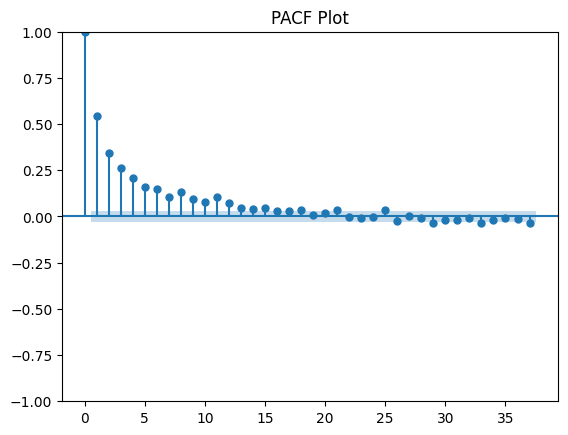

In [ ]:
#PACF Graph
plot_pacf(data['Dengue_Cases'])
plt.title("PACF Plot")
plt.show()

In [5]:
from statsmodels.tsa.arima.model import ARIMA

ts = data['Dengue_Cases']
p, d, q = 1, 1, 1
arima_model = ARIMA(ts, order=(p,d,q))
arima_fit = arima_model.fit()
print(f"ARIMA Model (order={p},{d},{q}) Trained Successfully")

ARIMA Model (order=1,1,1) Trained Successfully


In [9]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler

# 1. Load and Preprocess Data
try:
    # Using the 'data' variable already in memory or reloading if necessary
    ts = data['Dengue_Cases']
    p, d, q = 1, 1, 1
    arima_model = ARIMA(ts, order=(p,d,q))
    arima_fit = arima_model.fit()

    # 2. Calculate steps to reach end of 2027
    last_date = data.index[-1]
    target_date = pd.Timestamp('2027-12-31')
    steps = (target_date - last_date).days

    # 3. Generate Forecast and update forecast_df
    forecast_values = arima_fit.forecast(steps=steps)
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=steps, freq='D')
    forecast_df = pd.DataFrame({'Date': future_dates, 'Predicted_Cases': forecast_values.values})
    forecast_df.set_index('Date', inplace=True)

    # 4. Filter and Display 2026-2027 specifically
    prediction_26_27 = forecast_df.loc['2026-01-01':'2027-12-31']

    print('--- forecast_df updated with predictions through 2027 ---')
    print('\n--- Summary of Predictions for 2026-2027 ---')
    display(prediction_26_27.describe())

    print(f"Total predicted cases for 2026: {round(forecast_df.loc['2026-01-01':'2026-12-31', 'Predicted_Cases'].sum())}")
    print(f"Total predicted cases for 2027: {round(forecast_df.loc['2027-01-01':'2027-12-31', 'Predicted_Cases'].sum())}")

except Exception as e:
    print(f'An error occurred: {e}')

--- forecast_df updated with predictions through 2027 ---

--- Summary of Predictions for 2026-2027 ---


,Predicted_Cases
count,7.300000e+02
mean,1.235586e+01
std,4.799452e-14
min,1.235586e+01
25%,1.235586e+01
50%,1.235586e+01
75%,1.235586e+01
max,1.235586e+01


Total predicted cases for 2026: 4510
Total predicted cases for 2027: 4510


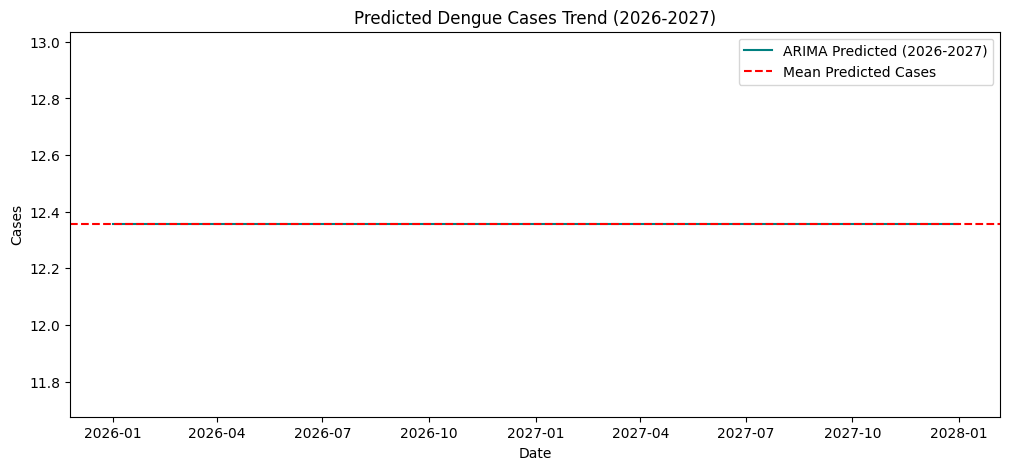

In [12]:
# ARIMA PREDICTED VS TREND (FOCUS 2026-2027)
prediction_26_27 = forecast_df.loc['2026-01-01':'2027-12-31']

plt.figure(figsize=(12,5))
plt.plot(prediction_26_27.index, prediction_26_27['Predicted_Cases'], label="ARIMA Predicted (2026-2027)", color='teal')
plt.axhline(y=prediction_26_27['Predicted_Cases'].mean(), color='r', linestyle='--', label="Mean Predicted Cases")
plt.legend()
plt.title("Predicted Dengue Cases Trend (2026-2027)")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.show()

In [ ]:
#MODEL EVALUATION
rmse = np.sqrt(mean_squared_error(data['Dengue_Cases'], predicted))
mae = mean_absolute_error(data['Dengue_Cases'], predicted)
print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 2.1456684189942234
MAE: 1.7118821443557357


In [ ]:
num_days = len(data)
start_date = data.index.min()
end_date = data.index.max()
print(f'The dataset contains {num_days} days.')
print(f'Date Range: {start_date.date()} to {end_date.date()}')

The dataset contains 5000 days.
Date Range: 2010-01-01 to 2023-09-09


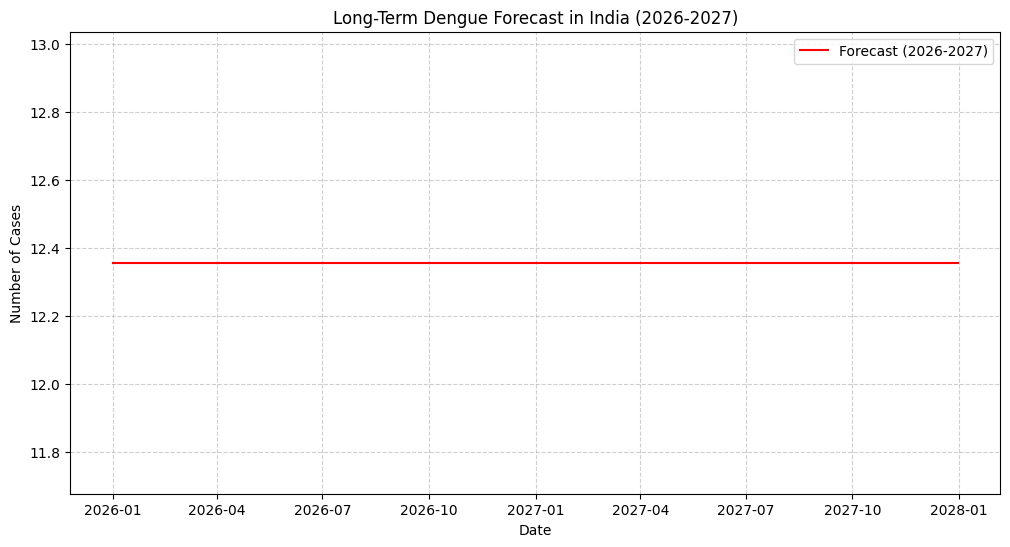

In [11]:
# UPDATED ARIMA FORECAST GRAPH FOR 2026-2027
prediction_26_27 = forecast_df.loc['2026-01-01':'2027-12-31']

plt.figure(figsize=(12,6))
plt.plot(prediction_26_27.index, prediction_26_27['Predicted_Cases'], color='red', label="Forecast (2026-2027)")
plt.legend()
plt.title("Long-Term Dengue Forecast in India (2026-2027)")
plt.xlabel("Date")
plt.ylabel("Number of Cases")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

--- Dengue Case Predictions for 2026 and 2027 ---


,Predicted_Cases
count,7.300000e+02
mean,1.899841e+01
std,2.737465e-13
min,1.899841e+01
25%,1.899841e+01
50%,1.899841e+01
75%,1.899841e+01
max,1.899841e+01


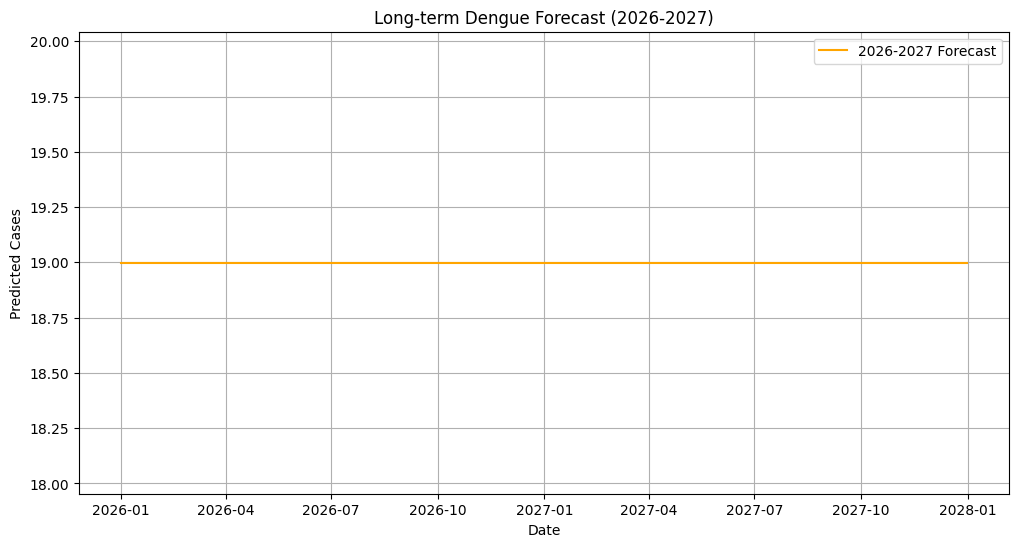

Total predicted cases for 2026: 6934
Total predicted cases for 2027: 6934


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    # Calculate steps needed to reach the end of 2027
    last_date = data.index[-1]
    target_date = pd.Timestamp('2027-12-31')
    steps = (target_date - last_date).days

    # Generate forecast
    forecast_values = arima_fit.forecast(steps=steps)
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=steps, freq='D')
    forecast_df = pd.DataFrame({'Date': future_dates, 'Predicted_Cases': forecast_values.values})
    forecast_df.set_index('Date', inplace=True)

    # Filter for 2026 and 2027 using explicit string slicing
    prediction_26_27 = forecast_df.loc['2026-01-01':'2027-12-31']

    print("--- Dengue Case Predictions for 2026 and 2027 ---")
    display(prediction_26_27.describe())

    # Visualization
    plt.figure(figsize=(12, 6))
    plt.plot(prediction_26_27.index, prediction_26_27['Predicted_Cases'], color='orange', label='2026-2027 Forecast')
    plt.title('Long-term Dengue Forecast (2026-2027)')
    plt.xlabel('Date')
    plt.ylabel('Predicted Cases')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Summing cases using explicit date ranges
    total_26 = round(forecast_df.loc['2026-01-01':'2026-12-31', 'Predicted_Cases'].sum())
    total_27 = round(forecast_df.loc['2027-01-01':'2027-12-31', 'Predicted_Cases'].sum())

    print(f"Total predicted cases for 2026: {total_26}")
    print(f"Total predicted cases for 2027: {total_27}")

except Exception as e:
    print(f"An error occurred: {e}")

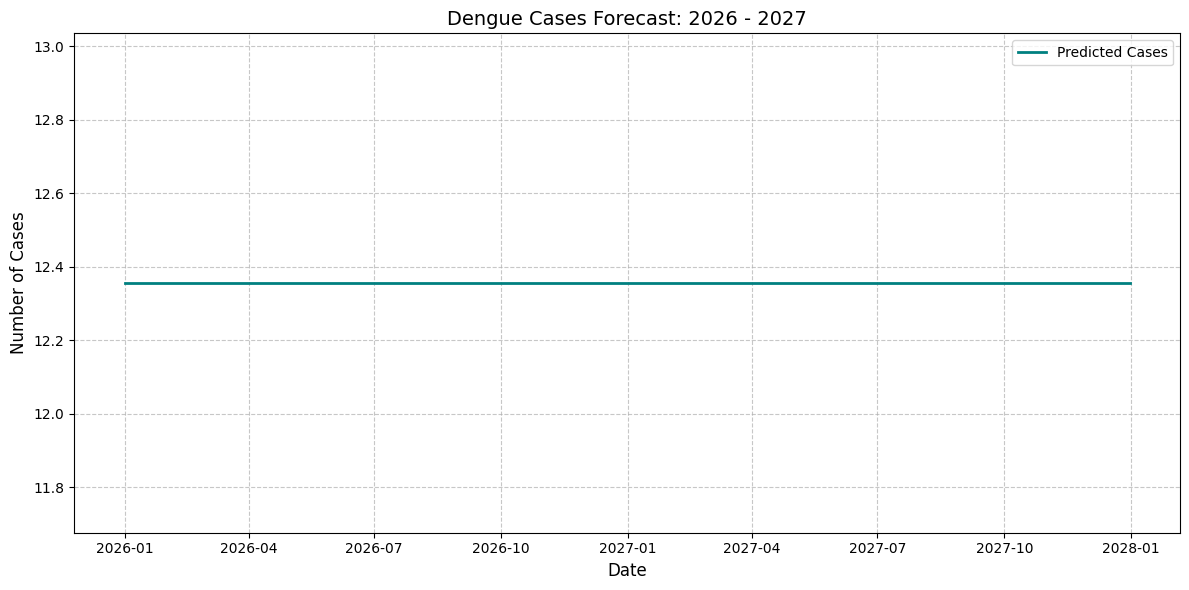

In [10]:
import matplotlib.pyplot as plt

# Filtering the forecast_df for the requested period
prediction_26_27 = forecast_df.loc['2026-01-01':'2027-12-31']

plt.figure(figsize=(12, 6))
plt.plot(prediction_26_27.index, prediction_26_27['Predicted_Cases'], color='teal', linewidth=2, label='Predicted Cases')

plt.title('Dengue Cases Forecast: 2026 - 2027', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Cases', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

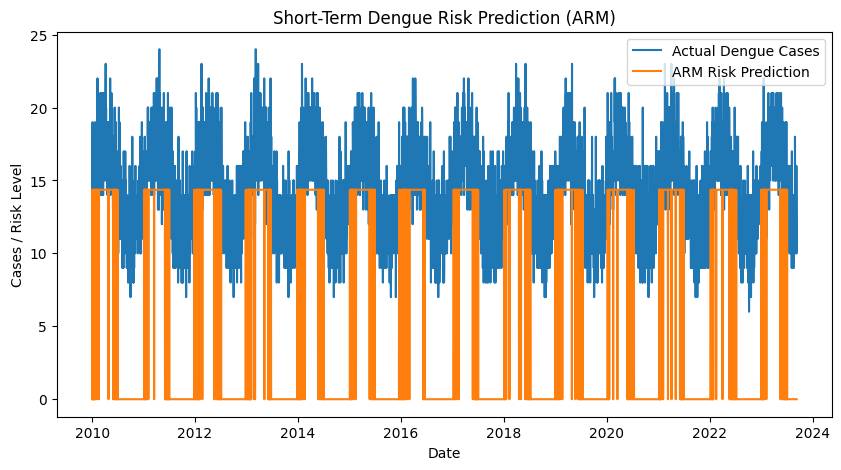

In [ ]:
#ARM SHORT-TERM RISK PREDICTION GRAPH
risk_prediction = arm_data['High_Temp'] & arm_data['High_Rain'] & arm_data['High_Humidity']
risk_prediction = risk_prediction.astype(int)
plt.figure(figsize=(10,5))
plt.plot(data.index, data['Dengue_Cases'], label="Actual Dengue Cases")
plt.plot(data.index,
         risk_prediction * data['Dengue_Cases'].mean(),
         label="ARM Risk Prediction")
plt.legend()
plt.title("Short-Term Dengue Risk Prediction (ARM)")
plt.xlabel("Date")
plt.ylabel("Cases / Risk Level")
plt.show()